# Анализ оптимизаций алгоритма построения множества Мальдеброта

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from scipy.stats import mannwhitneyu

df = pd.read_csv("results.csv", header=None, sep=";")

## Наивная реализация запуск на g++ (-O2)

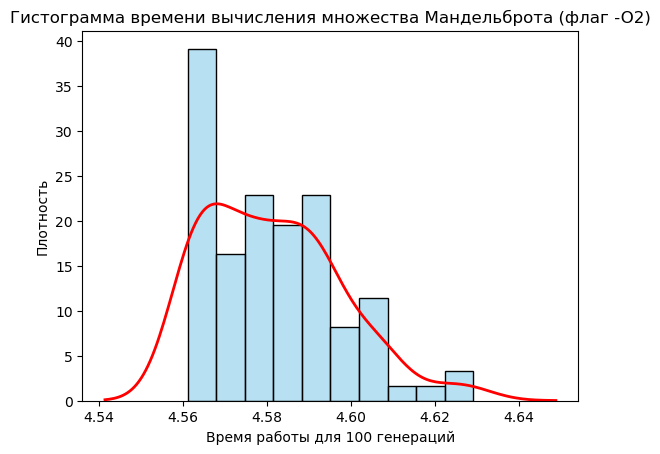

In [2]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Гистограмма времени вычисления множества Мандельброта (флаг -O2)")
plt.show() 

In [3]:
subset1_2_g = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset1_2_g.describe()

,4
count,90.000000
mean,4.581399
std,0.016124
min,4.561090
25%,4.566963
50%,4.579155
75%,4.591500
max,4.629160


In [4]:
mean = np.mean(subset1_2_g.iloc[:,4])
std = np.std(subset1_2_g.iloc[:,4], ddof=1)
n = len(subset1_2_g.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.003331283334848929
Доверительный интервал:
4.578068161109595 4.584730727779293


### Доверительный интервал времени работы обычной реализации (g++ -O2) от 4.578 до 4.585 секунд, среднее время работы 4.581 секунд

#### для случая когда мы еще и рисуем

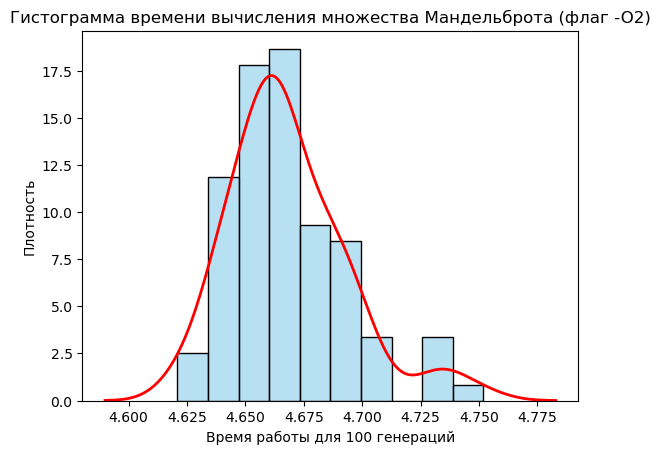

In [5]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Гистограмма времени вычисления множества Мандельброта (флаг -O2)")
plt.show() 

In [6]:
subset1_2_g_ = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset1_2_g_.describe()

,4
count,90.000000
mean,4.668253
std,0.025445
min,4.620880
25%,4.652493
50%,4.664710
75%,4.681765
max,4.751850


In [7]:
mean = np.mean(subset1_2_g_.iloc[:,4])
std = np.std(subset1_2_g_.iloc[:,4], ddof=1)
n = len(subset1_2_g_.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.005256850983296564
Доверительный интервал:
4.662995926794481 4.673509628761074


In [8]:
stat, p = mannwhitneyu(subset1_2_g.iloc[:,4], subset1_2_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 6.0
p-value = 5.970932867033835e-31


## Наивная реализация запуск на clang++ (-O2)

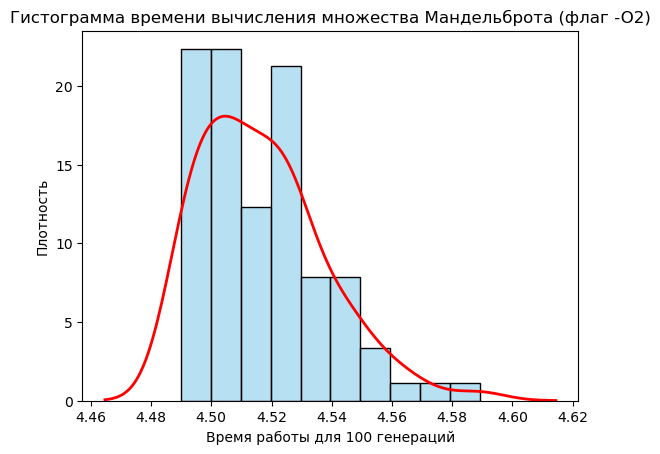

In [9]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Гистограмма времени вычисления множества Мандельброта (флаг -O2)")
plt.show() 

In [10]:
subset1_2_c = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" )&
    (df.iloc[:,3] == "MEASURE")
]

subset1_2_c.describe()

,4
count,90.000000
mean,4.516824
std,0.020691
min,4.489950
25%,4.500447
50%,4.513890
75%,4.527380
max,4.589170


In [11]:
mean = np.mean(subset1_2_c.iloc[:,4])
std = np.std(subset1_2_c.iloc[:,4], ddof=1)
n = len(subset1_2_c.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004274779433215753
Доверительный интервал:
4.512549109455673 4.521098668322104


### Доверительный интервал времени работы обычной реализации (clang++ -O2) от 4.513 до 4.521 секунд, среднее время работы 4.517 секунд

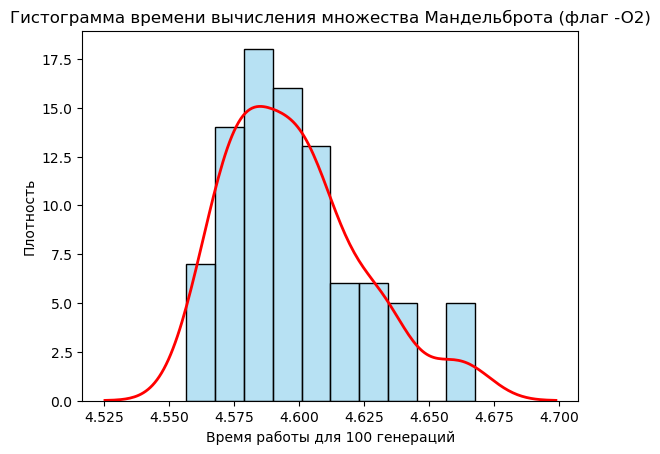

In [12]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Гистограмма времени вычисления множества Мандельброта (флаг -O2)")
plt.show() 

In [13]:
subset1_2_c_ = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" )&
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset1_2_c_.describe()

,4
count,90.000000
mean,4.597975
std,0.025667
min,4.556610
25%,4.579512
50%,4.595245
75%,4.611097
max,4.667550


In [14]:
mean = np.mean(subset1_2_c.iloc[:,4])
std = np.std(subset1_2_c.iloc[:,4], ddof=1)
n = len(subset1_2_c.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004274779433215753
Доверительный интервал:
4.512549109455673 4.521098668322104


In [15]:
stat, p = mannwhitneyu(subset1_2_c.iloc[:,4], subset1_2_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 56.0
p-value = 3.129724869949391e-30


## Наивная реализация запуск на g++ (-O3)

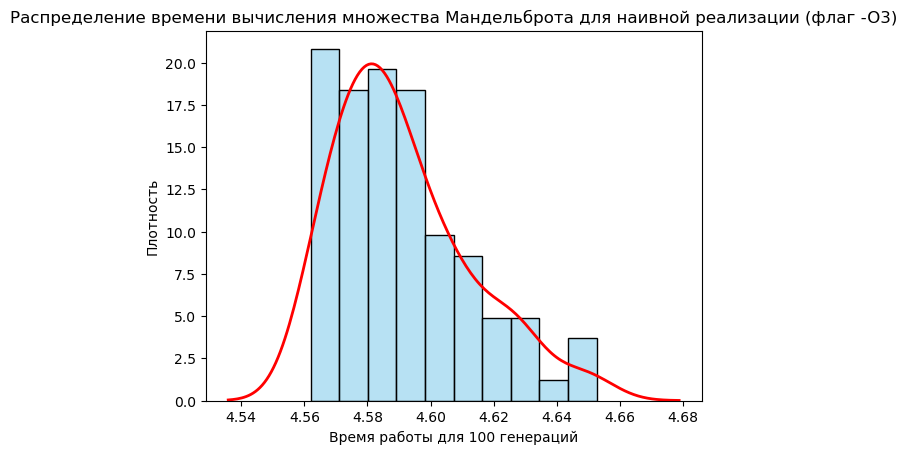

In [16]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для наивной реализации (флаг -O3)")
plt.show()

In [17]:
subset1_3_g = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" )&
    (df.iloc[:,3] == "MEASURE")
]

subset1_3_g.describe()

,4
count,90.000000
mean,4.591074
std,0.021427
min,4.562010
25%,4.576422
50%,4.586630
75%,4.602267
max,4.652680


In [18]:
mean = np.mean(subset1_3_g.iloc[:,4])
std = np.std(subset1_3_g.iloc[:,4], ddof=1)
n = len(subset1_3_g.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004426801986582769
Доверительный интервал:
4.586647309124529 4.595500913097694


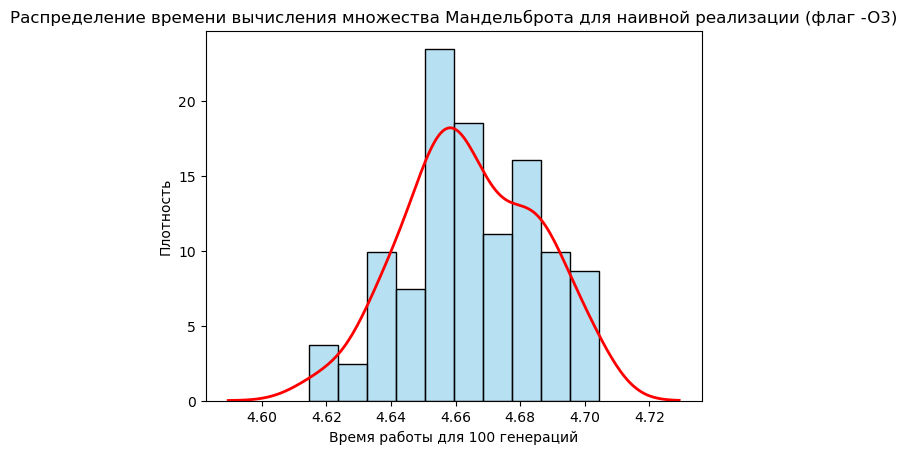

In [19]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для наивной реализации (флаг -O3)")
plt.show()

In [20]:
subset1_3_g_ = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" )&
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset1_3_g_.describe()

,4
count,90.000000
mean,4.664588
std,0.020441
min,4.614520
25%,4.651912
50%,4.662520
75%,4.682602
max,4.704260


In [21]:
mean = np.mean(subset1_3_g_.iloc[:,4])
std = np.std(subset1_3_g_.iloc[:,4], ddof=1)
n = len(subset1_3_g_.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004223141230327105
Доверительный интервал:
4.660364969880784 4.668811252341439


In [22]:
stat, p = mannwhitneyu(subset1_3_g.iloc[:,4], subset1_3_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 88.0
p-value = 8.942892151325712e-30


## Наивная реализация запуск на clang++ (-O3)

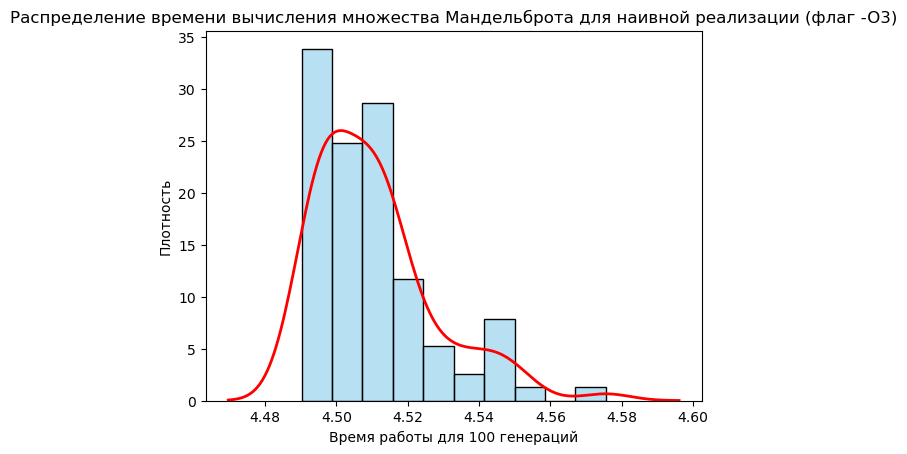

In [23]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для наивной реализации (флаг -O3)")
plt.show()

In [24]:
subset1_3_c = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" )  &
    (df.iloc[:,3] == "MEASURE")
]


subset1_3_c.describe()

,4
count,90.000000
mean,4.510389
std,0.016839
min,4.490240
25%,4.497853
50%,4.507305
75%,4.516348
max,4.575550


In [25]:
mean = np.mean(subset1_3_c.iloc[:,4])
std = np.std(subset1_3_c.iloc[:,4], ddof=1)
n = len(subset1_3_c.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0034788210676009656
Доверительный интервал:
4.506909956710176 4.513867598845378


### Доверительный интервал времени работы обычной реализации (clang++ -O3) от 4.507 до 4.514 секунд, среднее время работы 4.510 секунд

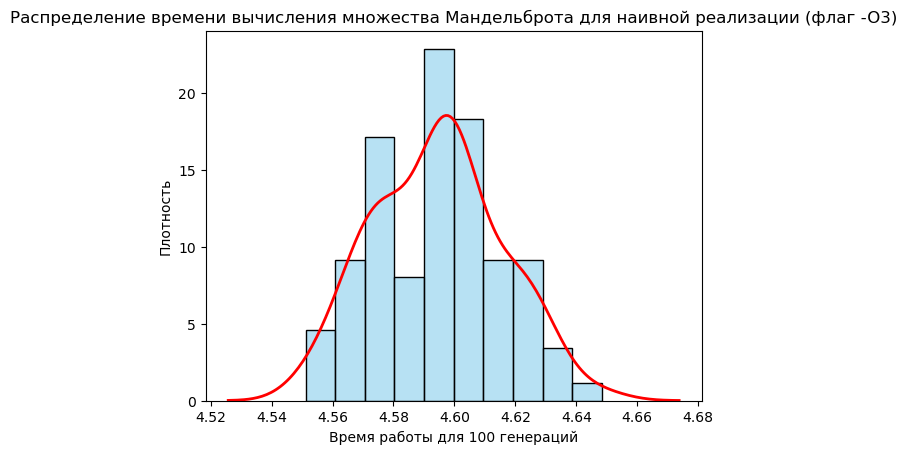

In [26]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для наивной реализации (флаг -O3)")
plt.show()

In [27]:
subset1_3_c_ = df[
    (df.iloc[:,0] == "mandelbrot1") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" )  &
    (df.iloc[:,3] == "MEASURE_DRAW")
]


subset1_3_c_.describe()

,4
count,90.000000
mean,4.594411
std,0.020784
min,4.551140
25%,4.576923
50%,4.595980
75%,4.606900
max,4.648380


In [28]:
mean = np.mean(subset1_3_c_.iloc[:,4])
std = np.std(subset1_3_c_.iloc[:,4], ddof=1)
n = len(subset1_3_c_.iloc[:,4])

alpha = 0.05 
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004293996340324335
Доверительный интервал:
4.590117225881897 4.5987052185625465


In [29]:
stat, p = mannwhitneyu(subset1_3_c.iloc[:,4], subset1_3_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 21.0
p-value = 9.835677688127474e-31


In [30]:
stat, p = mannwhitneyu(subset1_2_g.iloc[:,4], subset1_3_g.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 2984.5
p-value = 0.002312121531668025


In [31]:
stat, p = mannwhitneyu(subset1_2_g.iloc[:,4], subset1_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 7997.0
p-value = 1.4583855093268267e-29


In [32]:
stat, p = mannwhitneyu(subset1_2_g.iloc[:,4], subset1_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8065.0
p-value = 1.5647933041563531e-30


In [33]:
stat, p = mannwhitneyu(subset1_3_g.iloc[:,4], subset1_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8033.0
p-value = 4.4942105857273635e-30


In [34]:
stat, p = mannwhitneyu(subset1_3_g.iloc[:,4], subset1_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8078.0
p-value = 1.0168543518778213e-30


In [35]:
stat, p = mannwhitneyu(subset1_2_c.iloc[:,4], subset1_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 4786.5
p-value = 0.03523391479428396


### Сравнение всех оптимизаций для наивной реализации

| Компилятор/Оптимизация | Naive | 
|------------------------|---------------|
| g++ -O2                |  4.58 (+- 0.02)    | 
| g++ -O3                |  4.59 (+- 0.02)  | 
| clang++ -O2            |  4.52 (+- 0.02)    | 
| clang++ -O3            |  4.51 (+- 0.02)    | 

# Объяснение разницы работы реализаций

## G++ vs clang++ флаг -О2

Основное различие заключается в том, что g++ не разворачивает циклы, а clang++ - разворачивает. 

g++ :

<img src="godbolt_img/1_2.png" width="80%">

clang++:

<img src="godbolt_img/1_2_cyc.png" width="80%">

Также g++ более экономно использует регистры и сильнее обращается память (даже внутри циклов) в отличие от clang++ - он сильнее использует регистры, а все обращение в память старается вынести вне циклов. Особенно это можно видеть если посмотреть на ассемберный код, сгенерированный компиляторами для 
```c
double y0 = ((i_for_y - (double)SUPER_HEIGHT / 2) * DY) * SCALE_Y * params->zoom + params->center_y;
```

g++ :

<img src="godbolt_img/1_1gcc.png" width="80%">

clang++:

<img src="godbolt_img/1_1clang.png" width="80%">

## G++ и clang++ -O3 vs -O2

Различий нет, так как код, сгенерированный при данных оптимизациях не отличается от кода сгенерированного при -О2. Однако



## Реализация на массивах запуск на g++ с флагом -O2

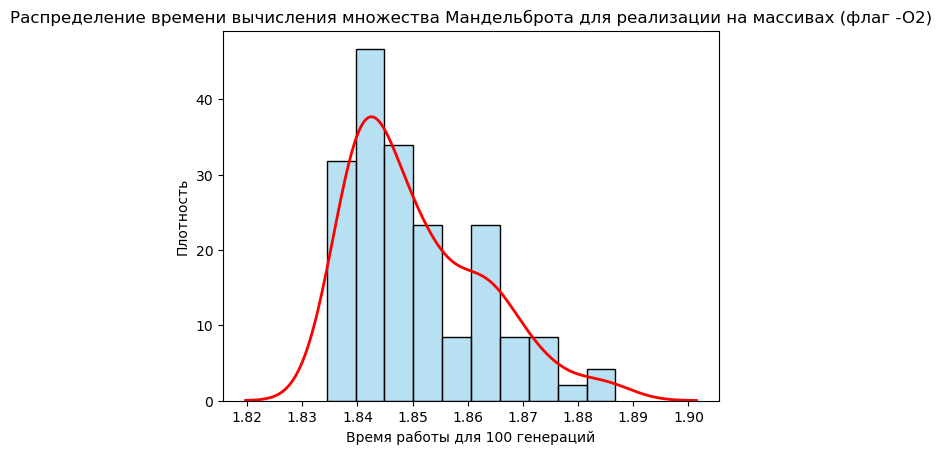

In [36]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O2)")
plt.show()

In [37]:
subset2_2_g = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset2_2_g.describe()

,4
count,90.000000
mean,1.850853
std,0.012057
min,1.834430
25%,1.841413
50%,1.847105
75%,1.860208
max,1.886750


In [38]:
mean = np.mean(subset2_2_g.iloc[:,4])
std = np.std(subset2_2_g.iloc[:,4], ddof=1)
n = len(subset2_2_g.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0024910194452607915
Доверительный интервал:
1.8483623138880727 1.8533443527785942


### Доверительный интервал времени работы реализации на массивах (g++ -O2) от 1.848 до 1.853 секунд, среднее время работы 1.850 секунд

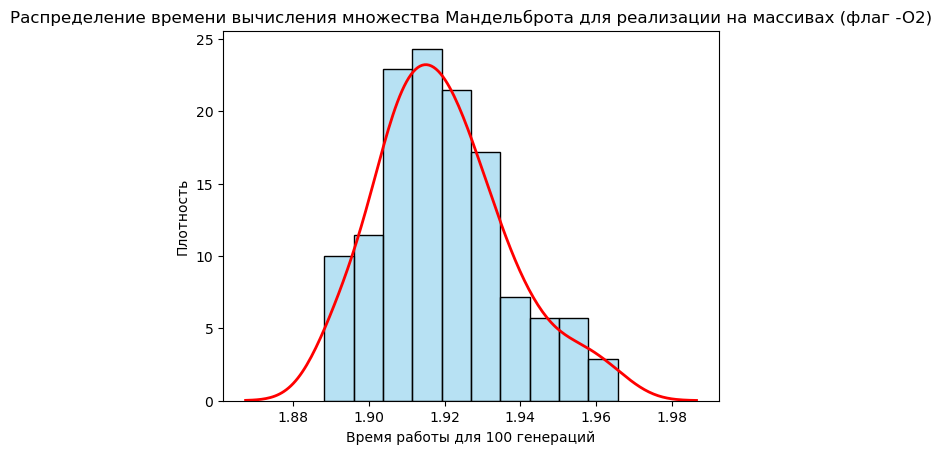

In [39]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O2)")
plt.show()

In [40]:
subset2_2_g_ = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset2_2_g_.describe()

,4
count,90.000000
mean,1.919540
std,0.017072
min,1.888200
25%,1.907125
50%,1.917350
75%,1.929787
max,1.965780


In [41]:
mean = np.mean(subset2_2_g_.iloc[:,4])
std = np.std(subset2_2_g_.iloc[:,4], ddof=1)
n = len(subset2_2_g_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.003526950138405284
Доверительный интервал:
1.916013160972706 1.9230670612495164


In [42]:
stat, p = mannwhitneyu(subset2_2_g.iloc[:,4], subset2_2_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 0.0
p-value = 4.886663443468531e-31


## Реализация на массивах запуск на clang++ с флагом -O2

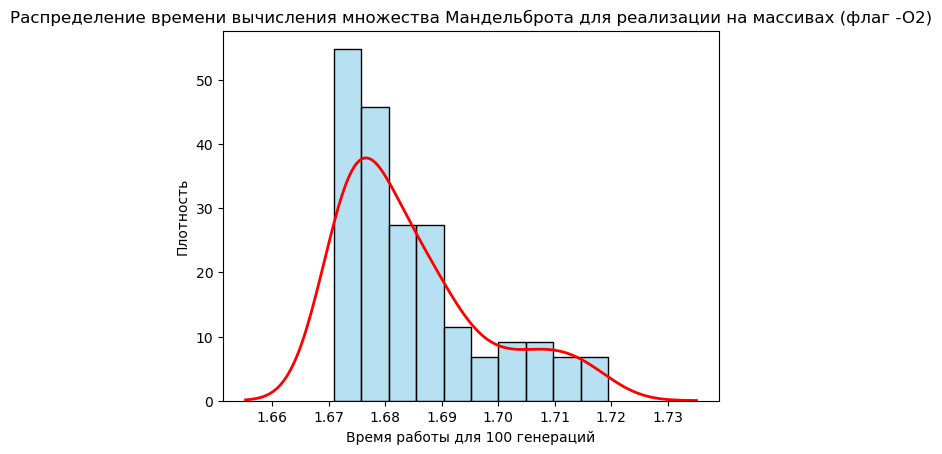

In [43]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O2)")
plt.show()

In [44]:
subset2_2_c = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset2_2_c.describe()

,4
count,90.000000
mean,1.684695
std,0.012826
min,1.670910
25%,1.675177
50%,1.680795
75%,1.689980
max,1.719450


In [45]:
mean = np.mean(subset2_2_c.iloc[:,4])
std = np.std(subset2_2_c.iloc[:,4], ddof=1)
n = len(subset2_2_c.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.002649833264102071
Доверительный интервал:
1.6820448334025644 1.6873444999307685


### Доверительный интервал времени работы реализации на массивах (clang++ -O2) от 1.682 до 1.687 секунд, среднее время работы 1.684 секунд

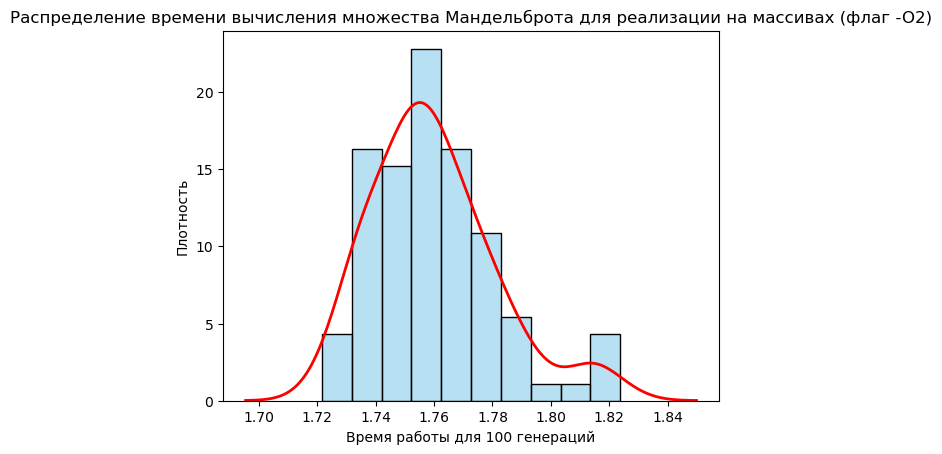

In [46]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O2)")
plt.show()

In [47]:
subset2_2_c_ = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset2_2_c_.describe()

,4
count,90.000000
mean,1.759861
std,0.021457
min,1.721580
25%,1.745642
50%,1.755915
75%,1.770105
max,1.823760


In [48]:
mean = np.mean(subset2_2_c_.iloc[:,4])
std = np.std(subset2_2_c_.iloc[:,4], ddof=1)
n = len(subset2_2_c_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004432973241330583
Доверительный интервал:
1.7554283600920026 1.764294306574664


In [49]:
stat, p = mannwhitneyu(subset2_2_c.iloc[:,4], subset2_2_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 0.0
p-value = 4.887343257947398e-31


## Реализация на массивах запуск на g++ с флагом -O3

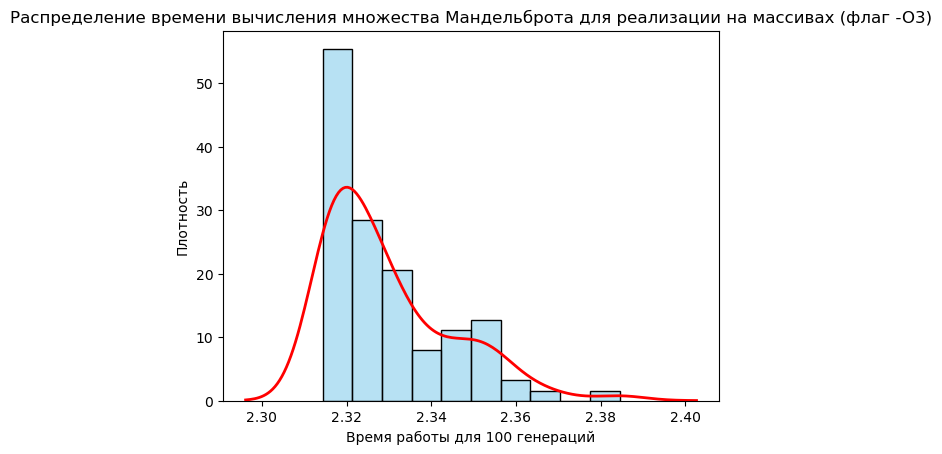

In [50]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O3)")
plt.show()

In [51]:
subset2_3_g = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset2_3_g.describe()

,4
count,90.000000
mean,2.329522
std,0.014909
min,2.314330
25%,2.316908
50%,2.324625
75%,2.337345
max,2.384460


In [52]:
mean = np.mean(subset2_3_g.iloc[:,4])
std = np.std(subset2_3_g.iloc[:,4], ddof=1)
n = len(subset2_3_g.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.003080223325475979
Доверительный интервал:
2.326442221118968 2.3326026677699203


### Доверительный интервал времени работы реализации на массивах (g++ -O3) от 2.326 до 2.332 секунд, среднее время работы 2.330 секунд

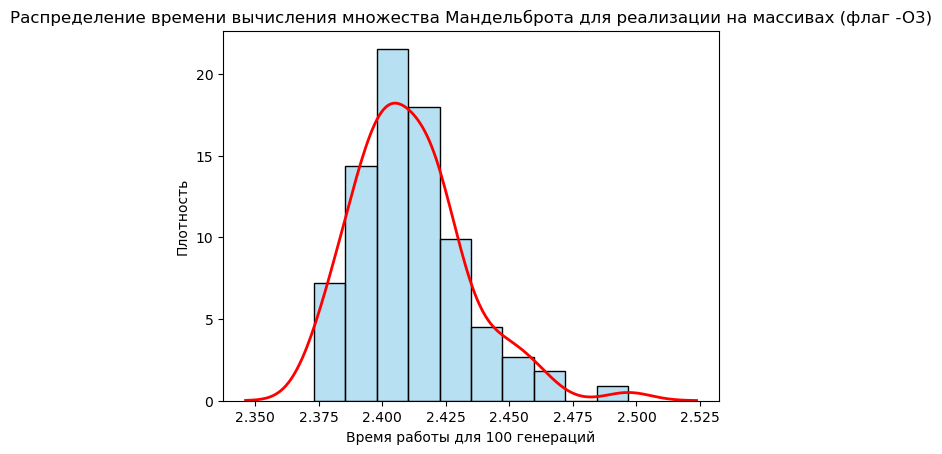

In [53]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O3)")
plt.show()

In [54]:
subset2_3_g_ = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset2_3_g_.describe()

,4
count,90.000000
mean,2.410968
std,0.022005
min,2.373180
25%,2.396117
50%,2.407620
75%,2.422150
max,2.496770


In [55]:
mean = np.mean(subset2_3_g_.iloc[:,4])
std = np.std(subset2_3_g_.iloc[:,4], ddof=1)
n = len(subset2_3_g_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)
pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004546141633243601
Доверительный интервал:
2.406421858366756 2.4155141416332433


In [56]:
stat, p = mannwhitneyu(subset2_3_g.iloc[:,4], subset2_3_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8.0
p-value = 6.382541793371403e-31


## Реализация на массивах запуск на clang++ с флагом -O3

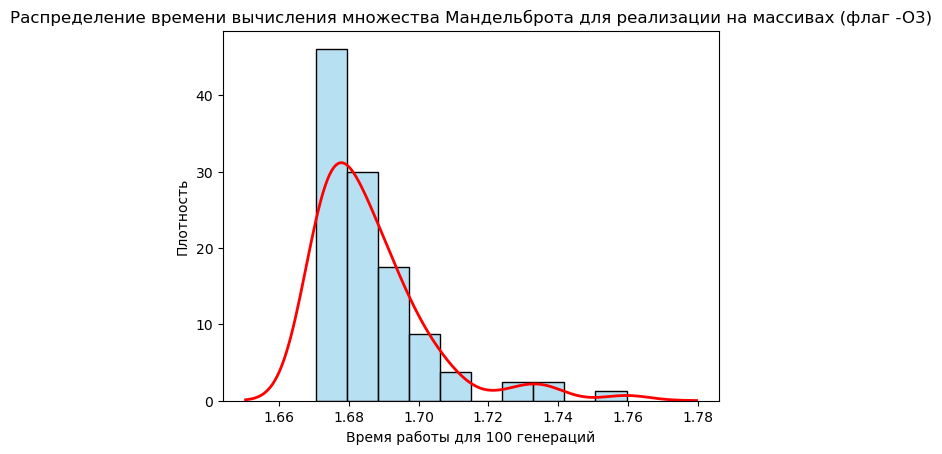

In [57]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O3)")
plt.show()

In [58]:
subset2_3_c = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset2_3_c.describe()

,4
count,90.000000
mean,1.686163
std,0.016453
min,1.670500
25%,1.674515
50%,1.681905
75%,1.692620
max,1.759610


In [59]:
mean = np.mean(subset2_3_c.iloc[:,4])
std = np.std(subset2_3_c.iloc[:,4], ddof=1)
n = len(subset2_3_c.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0033991433752531787
Доверительный интервал:
1.6827634121803023 1.6895616989308087


### Доверительный интервал времени работы реализации на массивах (clang++ -O3) от 1.683 до 1.670 секунд, среднее время работы 1.686 секунд

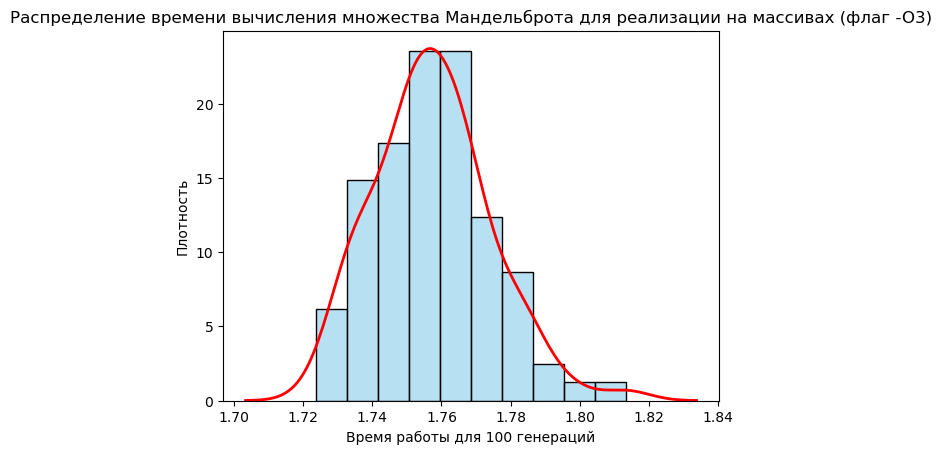

In [60]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для реализации на массивах (флаг -O3)")
plt.show()

In [61]:
subset2_3_c_ = df[
    (df.iloc[:,0] == "mandelbrot2") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset2_3_c_.describe()

,4
count,90.000000
mean,1.757392
std,0.016612
min,1.723690
25%,1.746548
50%,1.756290
75%,1.767352
max,1.813420


In [62]:
mean = np.mean(subset2_3_c_.iloc[:,4])
std = np.std(subset2_3_c_.iloc[:,4], ddof=1)
n = len(subset2_3_c_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0034320485573090163
Доверительный интервал:
1.7539596181093575 1.7608237152239754


In [63]:
stat, p = mannwhitneyu(subset2_3_c.iloc[:,4], subset2_3_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 76.0
p-value = 6.038317311254515e-30


In [93]:
stat, p = mannwhitneyu(subset2_2_g.iloc[:,4], subset2_3_g.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 0.0
p-value = 4.887343257947398e-31


In [94]:
stat, p = mannwhitneyu(subset2_2_g.iloc[:,4], subset2_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8100.0
p-value = 4.8876831996054065e-31


In [95]:
stat, p = mannwhitneyu(subset2_2_g.iloc[:,4], subset2_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8100.0
p-value = 4.88700333923563e-31


In [96]:
stat, p = mannwhitneyu(subset2_3_g.iloc[:,4], subset2_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8100.0
p-value = 4.8876831996054065e-31


In [97]:
stat, p = mannwhitneyu(subset2_3_g.iloc[:,4], subset2_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8100.0
p-value = 4.88700333923563e-31


In [98]:
stat, p = mannwhitneyu(subset2_2_c.iloc[:,4], subset2_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 4009.5
p-value = 0.908890753338093


### Сравнений всех оптимизаций для реализации на массивах

# Объяснение разницы работы реализаций

## G++ vs clang++ флаг -О2

Clang++ активнее использует fma и simd инструкции и меньше обращается к памяти в циклах, например для

```c
for(int j = 0; j < 4; j++){x0[j]= X0 + j*dx;};
```

clang++ заменил на SIMD вариант, а g++ - нет и при этом обращается в память.

g++ :

<img src="godbolt_img/2_2gcc.png" width="80%">

clang++:

<img src="godbolt_img/2_2clang.png" width="80%">

Также clang++ на данном уровне оптимизации развернул циклы в отличие от g++

g++ :

<img src="godbolt_img/2_3gcc.png" width="80%">

clang++:

<img src="godbolt_img/2_3clang.png" width="80%">

## G++ -O2 vs g++ -О3

Intrinsic инструкции стали применяться реже, также стало больше обращений в память, примеры на скриншотах. Например, для

```c
for(int j = 0; j < 4; j++){x2[j]= x[j] * x[j];}  (1)

for(int j = 0; j < 4; j++){y2[j]= y[j] * y[j];}
```
g++ на уровне оптимизации -O3 заменил одну intrinsic инструкцию на 4 умножения и одно обращения в память

g++ -O2 :

<img src="godbolt_img/2_4gcc.png" width="80%">

g++ -O3 :

<img src="godbolt_img/2_4c.png" width="80%">


## Реализация SIMD запуск на g++ с флагом -O2

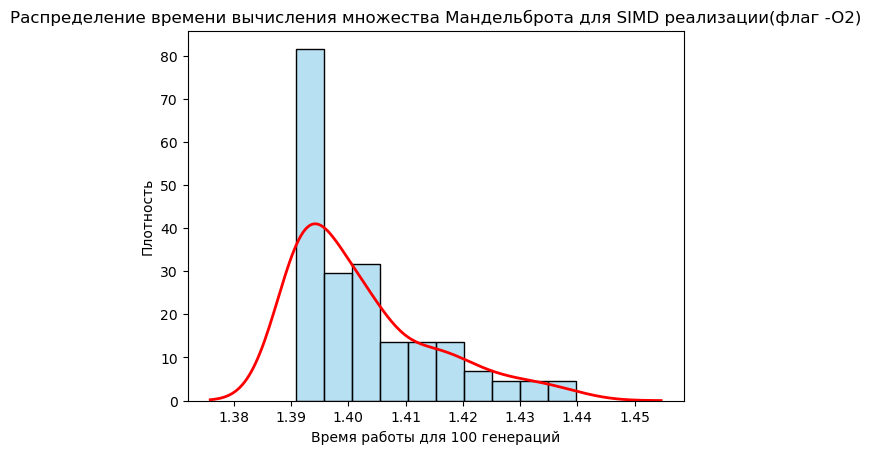

In [64]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O2)")
plt.show()

In [65]:
subset3_2_g = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE")
]


subset3_2_g.describe()

,4
count,90.000000
mean,1.402321
std,0.012207
min,1.390780
25%,1.391807
50%,1.397925
75%,1.406985
max,1.439740


In [66]:
mean = np.mean(subset3_2_g.iloc[:,4])
std = np.std(subset3_2_g.iloc[:,4], ddof=1)
n = len(subset3_2_g.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0025220270404748405
Доверительный интервал:
1.3997993062928584 1.4048433603738082


### Доверительный интервал времени работы SIMD реализации(g++ -O2) от 1.400 до 1.404 секунд, среднее время работы 1.402 секунд

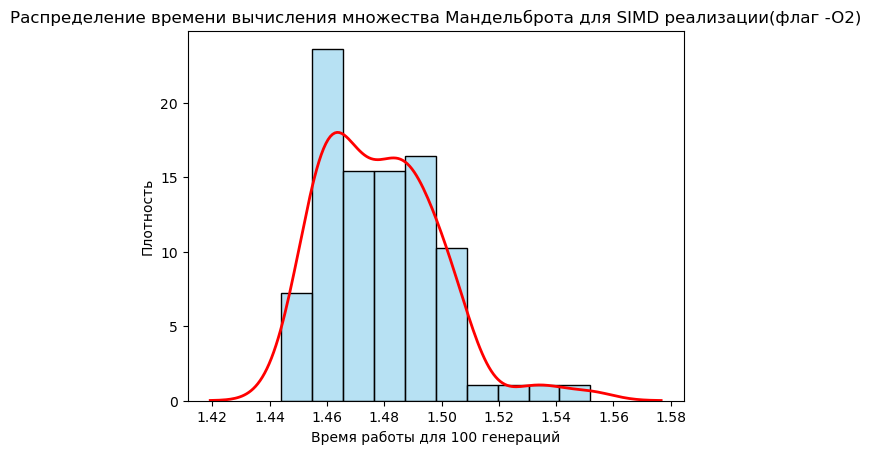

In [67]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O2)")
plt.show()

In [68]:
subset3_2_g_ = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]


subset3_2_g_.describe()

,4
count,90.000000
mean,1.478476
std,0.020232
min,1.443950
25%,1.462110
50%,1.476670
75%,1.490775
max,1.551960


In [69]:
mean = np.mean(subset3_2_g_.iloc[:,4])
std = np.std(subset3_2_g_.iloc[:,4], ddof=1)
n = len(subset3_2_g_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0041798067731924635
Доверительный интервал:
1.4742958598934743 1.4826554734398592


In [70]:
stat, p = mannwhitneyu(subset3_2_g.iloc[:,4], subset3_2_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 0.0
p-value = 4.887343257947398e-31


## Реализация SIMD запуск на clang++ с флагом -O2

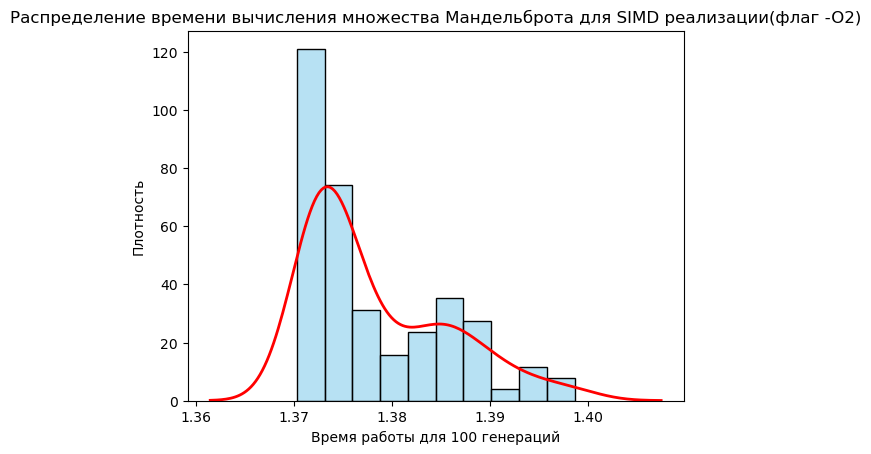

In [71]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O2)")
plt.show()

In [72]:
subset3_2_c = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" )&
    (df.iloc[:,3] == "MEASURE")
]

subset3_2_c.describe()

,4
count,90.000000
mean,1.378329
std,0.007247
min,1.370260
25%,1.372440
50%,1.375115
75%,1.384025
max,1.398670


In [73]:
mean = np.mean(subset3_2_c.iloc[:,4])
std = np.std(subset3_2_c.iloc[:,4], ddof=1)
n = len(subset3_2_c.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0014971343527156239
Доверительный интервал:
1.3768317545361732 1.3798260232416046


### Доверительный интервал времени работы SIMD реализации(clang++ -O2) от 1.377 до 1.340 секунд, среднее время работы 1.378 секунд

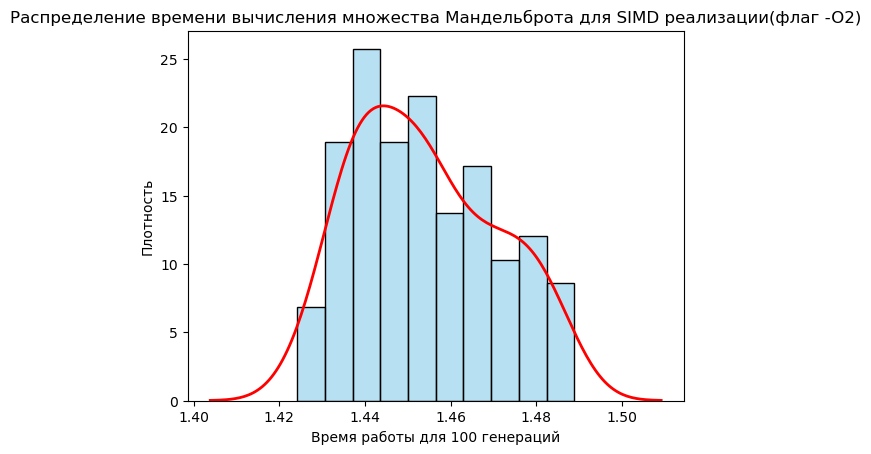

In [74]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)

plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O2)")
plt.show()

In [75]:
subset3_2_c_ = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O2") &
    (df.iloc[:,1] == "clang++" )&
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset3_2_c_.describe()

,4
count,90.000000
mean,1.454001
std,0.016634
min,1.424150
25%,1.440033
50%,1.451860
75%,1.467118
max,1.488840


In [76]:
mean = np.mean(subset3_2_c_.iloc[:,4])
std = np.std(subset3_2_c_.iloc[:,4], ddof=1)
n = len(subset3_2_c_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.003436519460597975
Доверительный интервал:
1.4505641472060689 1.4574371861272646


In [77]:
stat, p = mannwhitneyu(subset3_2_c.iloc[:,4], subset3_2_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 0.0
p-value = 4.885643893821253e-31


## Реализация SIMD запуск на g++ с флагом -O3

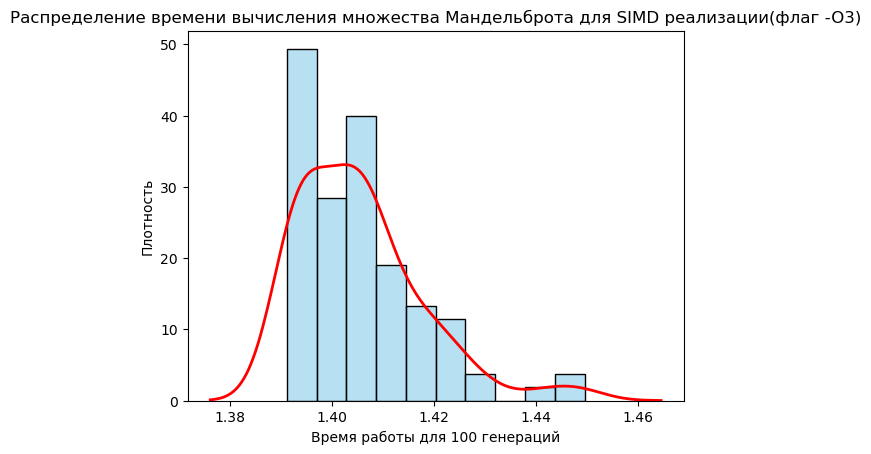

In [78]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)
plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O3)")
plt.show()

In [79]:
subset3_3_g = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset3_3_g.describe()

,4
count,90.000000
mean,1.405354
std,0.012299
min,1.391120
25%,1.394955
50%,1.403880
75%,1.410308
max,1.449570


In [80]:
mean = np.mean(subset3_3_g.iloc[:,4])
std = np.std(subset3_3_g.iloc[:,4], ddof=1)
n = len(subset3_3_g.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0025409023099825278
Доверительный интервал:
1.4028133199122397 1.4078951245322047


### Доверительный интервал времени работы SIMD реализации(g++ -O3) от 1.403 до 1.408 секунд, среднее время работы 1.405 секунд

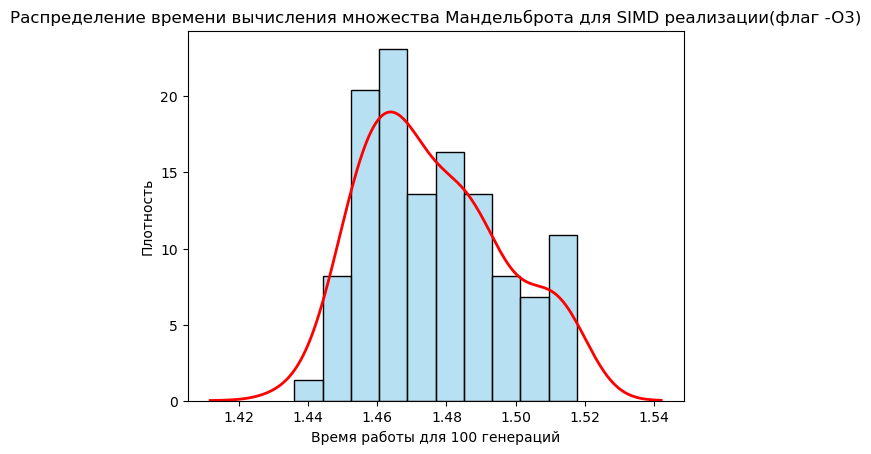

In [81]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)
plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O3)")
plt.show()

In [82]:
subset3_3_g_ = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "g++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset3_3_g_.describe()

,4
count,90.000000
mean,1.476289
std,0.019938
min,1.436080
25%,1.460987
50%,1.471865
75%,1.488948
max,1.517680


In [83]:
mean = np.mean(subset3_3_g_.iloc[:,4])
std = np.std(subset3_3_g_.iloc[:,4], ddof=1)
n = len(subset3_3_g_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.004119131567721262
Доверительный интервал:
1.472170201765612 1.4804084649010547


In [84]:
stat, p = mannwhitneyu(subset3_3_g.iloc[:,4], subset3_3_g_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 8.0
p-value = 6.381657482038062e-31


## Реализация SIMD запуск на clang++ с флагом -O3

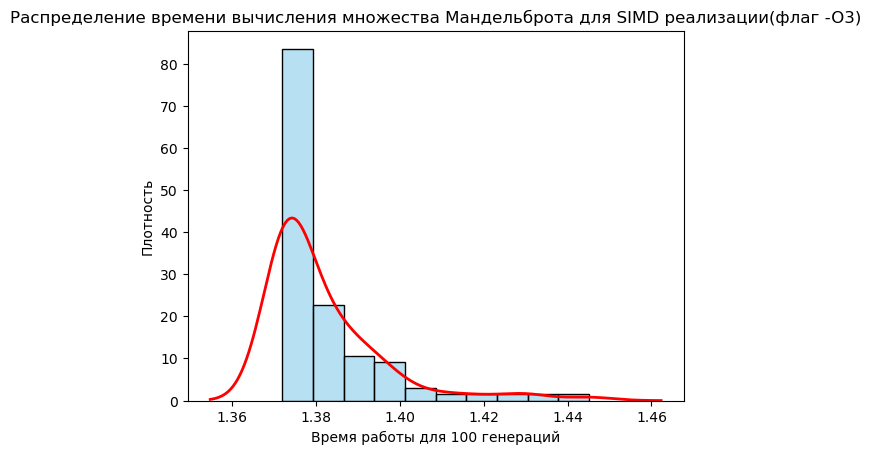

In [85]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)
plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O3)")
plt.show()

In [86]:
subset3_3_c = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE")
]

subset3_3_c.describe()

,4
count,90.000000
mean,1.381775
std,0.014085
min,1.372040
25%,1.372583
50%,1.375470
75%,1.385683
max,1.445130


In [87]:
mean = np.mean(subset3_3_c.iloc[:,4])
std = np.std(subset3_3_c.iloc[:,4], ddof=1)
n = len(subset3_3_c.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.0029099989044044654
Доверительный интервал:
1.3788648899844842 1.3846848877932934


### Доверительный интервал времени работы SIMD реализации(clang++ -O3) от 1.379 до 1.385 секунд, среднее время работы 1.381 секунд

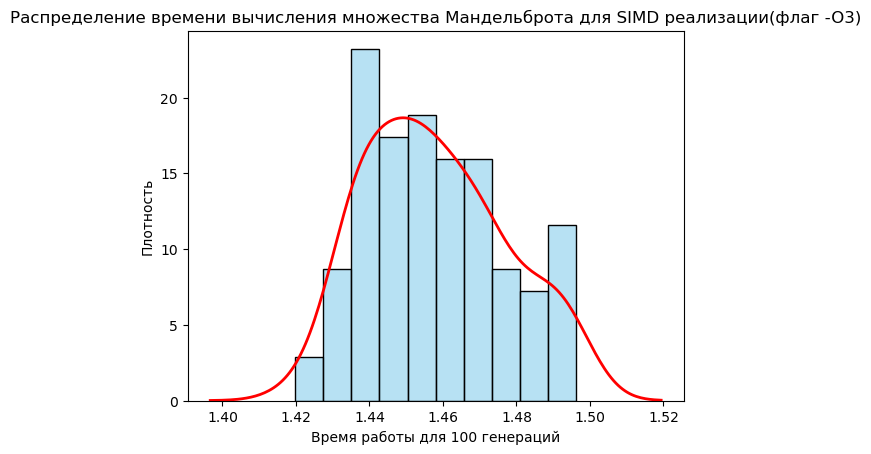

In [88]:
filtered = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++") &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

sns.histplot(
    data=filtered,
    x=filtered.iloc[:,4],
    bins=10,
    stat="density",
    color="skyblue",
    alpha=0.6
)

sns.kdeplot(
    data=filtered,
    x=filtered.iloc[:,4],
    color="red",
    linewidth=2
)
plt.xlabel("Время работы для 100 генераций")
plt.ylabel("Плотность")
plt.title("Распределение времени вычисления множества Мандельброта для SIMD реализации(флаг -O3)")
plt.show()

In [89]:
subset3_3_c_ = df[
    (df.iloc[:,0] == "mandelbrot3") &
    (df.iloc[:,2] == "O3") &
    (df.iloc[:,1] == "clang++" ) &
    (df.iloc[:,3] == "MEASURE_DRAW")
]

subset3_3_c_.describe()

,4
count,90.000000
mean,1.458007
std,0.018926
min,1.419750
25%,1.441785
50%,1.455405
75%,1.471208
max,1.496280


In [90]:
mean = np.mean(subset3_3_c_.iloc[:,4])
std = np.std(subset3_3_c_.iloc[:,4], ddof=1)
n = len(subset3_3_c_.iloc[:,4])

alpha = 0.05  
z = norm.ppf(1 - alpha/2)

pogr = z * std / np.sqrt(n)
print(f"погрешность = {pogr}")

lower = mean - pogr
upper = mean + pogr

print("Доверительный интервал:")
print(lower, upper)

погрешность = 0.00391010006862113
Доверительный интервал:
1.4540972332647122 1.4619174334019542


In [91]:
stat, p = mannwhitneyu(subset3_3_c.iloc[:,4], subset3_3_c_.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 30.0
p-value = 1.3253173769342635e-30


In [99]:
stat, p = mannwhitneyu(subset3_2_g.iloc[:,4], subset3_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 7902.0
p-value = 3.096039645019514e-28


In [100]:
stat, p = mannwhitneyu(subset3_2_g.iloc[:,4], subset3_3_g.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 3199.0
p-value = 0.014964278524350512


In [101]:
stat, p = mannwhitneyu(subset3_2_g.iloc[:,4], subset3_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 7284.0
p-value = 2.2259313240425852e-20


In [102]:
stat, p = mannwhitneyu(subset3_3_g.iloc[:,4], subset3_2_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 7979.5
p-value = 2.5733706521575555e-29


In [103]:
stat, p = mannwhitneyu(subset3_3_g.iloc[:,4], subset3_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 7423.0
p-value = 4.983557356148387e-22


In [104]:
stat, p = mannwhitneyu(subset3_2_c.iloc[:,4], subset3_3_c.iloc[:,4], alternative='two-sided')

print("U =", stat)
print("p-value =", p)

U = 3632.5
p-value = 0.2328602728344037


## G++ vs clang++ флаг -О2

На данном уровне оптимизации clang++ работает быстрее из-за развертки циклов

g++ :

<img src="godbolt_img/3.png" width="80%">

clang++:

<img src="godbolt_img/3c.png" width="80%">

Для флага оптимизации -O3 аналогично -О2 (оба компилятора генерируют почти идентичный код)

# Доказательство отсутствия тротлинга при замерах

## Наивная реализация

### G++ -O2

##### Тест 1:

<img src="tests_img/Screenshot_20260413_231523.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_231835.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_232140.png" width="60%">


### Clang++ -O2

##### Тест 1:

<img src="tests_img/Screenshot_20260413_232449.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_232749.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_233046.png" width="60%">


### G++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260413_233412.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_233722.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_234036.png" width="60%">


### Clang++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260413_234348.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_234646.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_234943.png" width="60%">

## Реализация на массивах

### G++ -O2 

##### Тест 1:

<img src="tests_img/Screenshot_20260413_235125.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_235303.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_235430.png" width="60%">


### Clang++ -O2

##### Тест 1:

<img src="tests_img/Screenshot_20260413_235554.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260413_235710.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260413_235825.png" width="60%">


### G++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260414_000054.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_000231.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_000405.png" width="60%">


### Clang++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260414_000640.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_000957.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_001110.png" width="60%">

## SIMD Реализация

### G++ -O2

##### Тест 1:

<img src="tests_img/Screenshot_20260414_001425.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_001540.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_001641.png" width="60%">


### Clang++ -O2

##### Тест 1:

<img src="tests_img/Screenshot_20260414_001757.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_001859.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_002000.png" width="60%">


### G++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260414_002115.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_002217.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_002320.png" width="60%">


### Clang++ -O3

##### Тест 1:

<img src="tests_img/Screenshot_20260414_002435.png" width="60%">

##### Тест 2:

<img src="tests_img/Screenshot_20260414_002536.png" width="60%">

##### Тест 3: 
<img src="tests_img/Screenshot_20260414_002636.png" width="60%">